Import packages and construct list of DEMs (stored in dems var).

In [1]:
from pathlib import Path #to access data by path
import topotoolbox as ttb #to handle data
import matplotlib.pyplot as plt #for plotting
import numpy as np #for handling large amounts of data (arrays not lists)
from datetime import datetime as dt #to process the date of dems
import rasterio #for reprojecting and resampling raster data
from rasterio.warp import reproject, Resampling


rasterFolder = Path('Snow Depth Rasters')
dems = [] #snow depth dems

# #loop through each file in snow rasters folder
for file in Path("Snow Depth Rasters").iterdir():
    #ensure file is .tif
    if file.is_file() and file.suffix.lower() == '.tif':
        dem = ttb.read_tif(file)
        dems.append(dem)

bsDem = ttb.read_tif(r"NonDepthData\MTBS_Resampled_1m.tif") #raster containing burn severity data
sfDem = ttb.read_tif(r"NonDepthData\DEM_063025_SnowFree.tif") #raster of snow free slope

iVarDems = [] #dems of indepent variables ex: burn severity

iVarDems.append(sfDem)
iVarDems.append(bsDem)

Create a box plot based on parameters: data (array of numerical values), title (plot title), dataLabel (label describing the numerical data), and criteriaLabel (special criteria this dataset meets).

In [2]:
def makeBoxPlot(data : np.array, title : str, dataLabel : str, criteriaLabel : str):
    if len(data) <= 1: return

    #Setup plot
    plt.figure(figsize=(8, 4))
    plt.boxplot(data)

    #Setup labels
    plt.title(title)
    plt.xlabel(criteriaLabel)
    plt.ylabel(dataLabel)

    #Show plot
    plt.show()

Create a scatter plot based on parameters: xData, yData, title, xLabel, and yLabel

In [3]:
def makeScatterPlot(xData : np.array, yData : np.array, title : str, xLabel : str, yLabel : str):
    
    #Setup graph
    plt.figure(figsize=(8, 4))
    plt.scatter(xData, yData)

    #Setup labels
    plt.title(title)
    plt.xlabel(xLabel)
    plt.ylabel(yLabel)

    #Show graph
    plt.show()

Function that takes the raw name of a dem and processes it into a readable format.

In [4]:
def processDemName(rawName : str):
    rawDate = rawName.split("_")[1] #get date string from name (will take whatever string comes after the first underscore)
    date = dt.strptime(rawDate, "%m%d%y").date() #get date object from string
    name = "Lidar drone data - " + date.strftime("%m/%d/%y") #convert date object back to string
    return name

-import SD rasters, import DEM, LAI, burn severity

-use topotoolbox to generate slope, aspect, northness, eastness rasters

-create scatter plots of snow depth on each date vs independent variables

Process snow depth data and make plots.

RESOLUTIONS DID NOT MATCH: SD_011426_1m
RESOLUTIONS DID NOT MATCH: SD_011426_1m


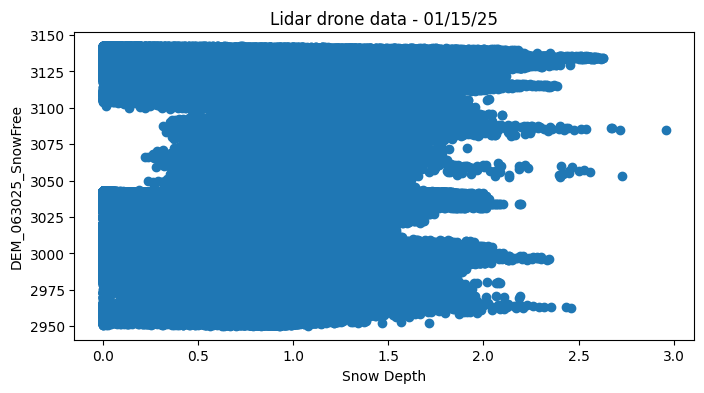

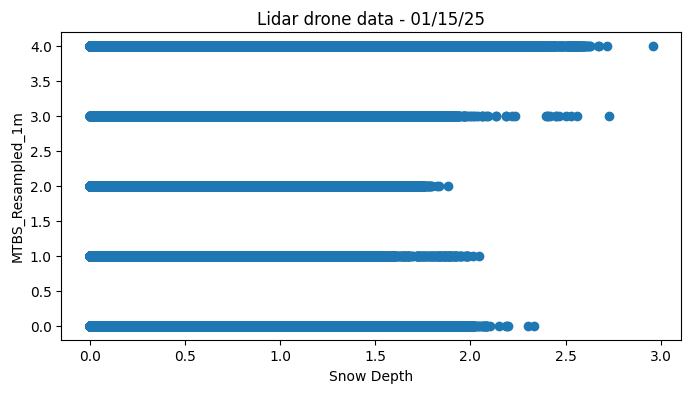

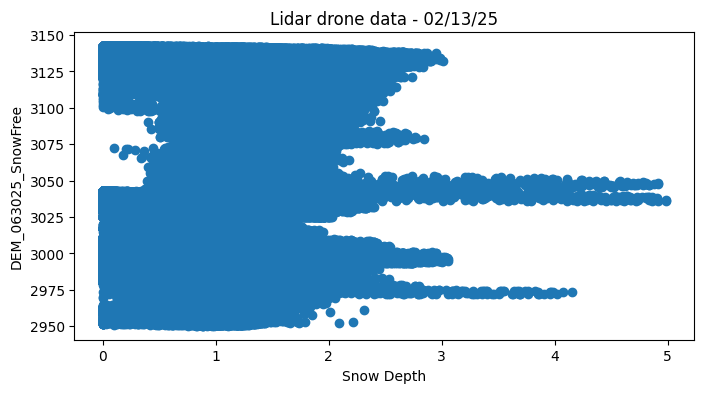

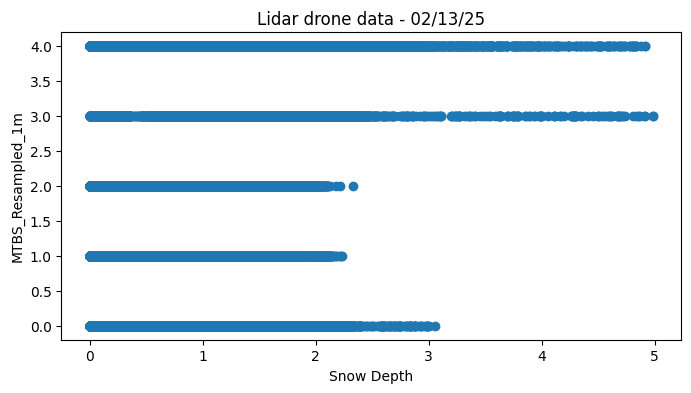

RESOLUTIONS DID NOT MATCH: SD_031225_1m
RESOLUTIONS DID NOT MATCH: SD_031225_1m
RESOLUTIONS DID NOT MATCH: SD_032326_1m
RESOLUTIONS DID NOT MATCH: SD_032326_1m


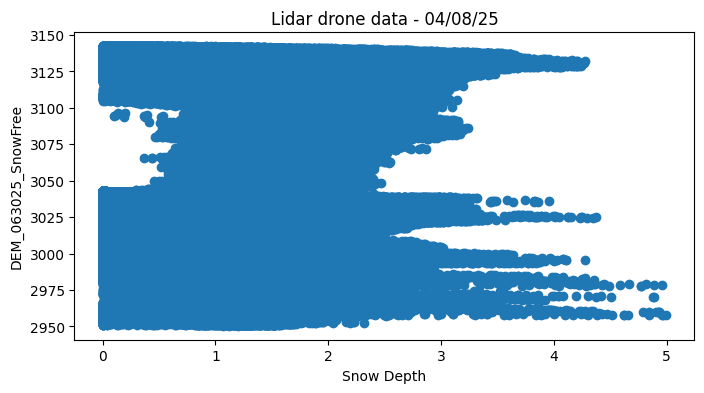

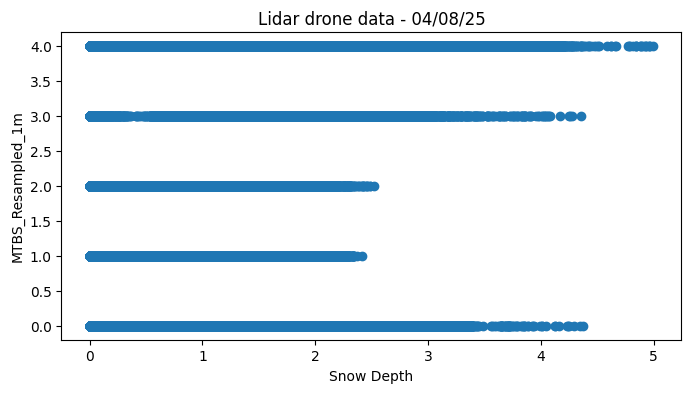

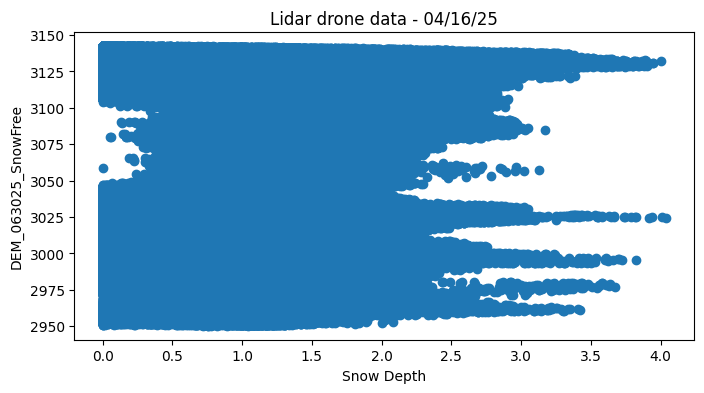

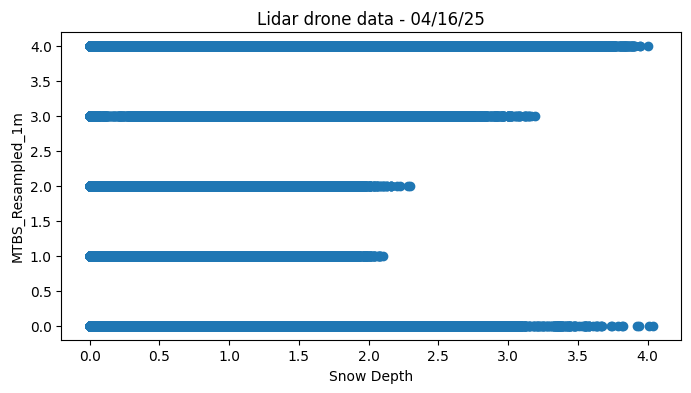

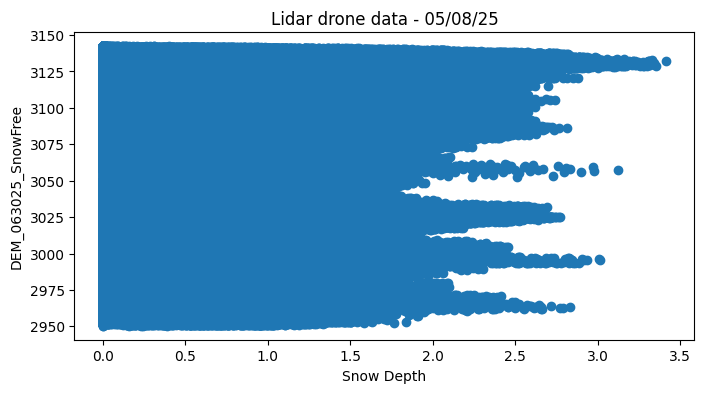

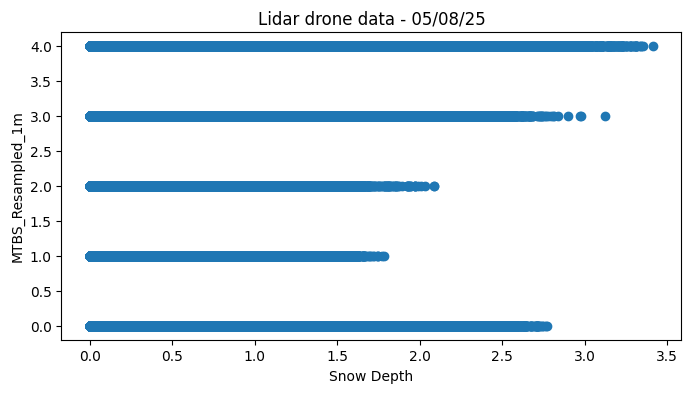

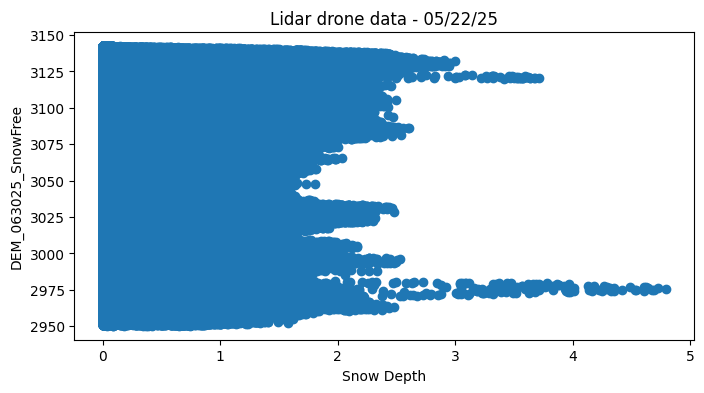

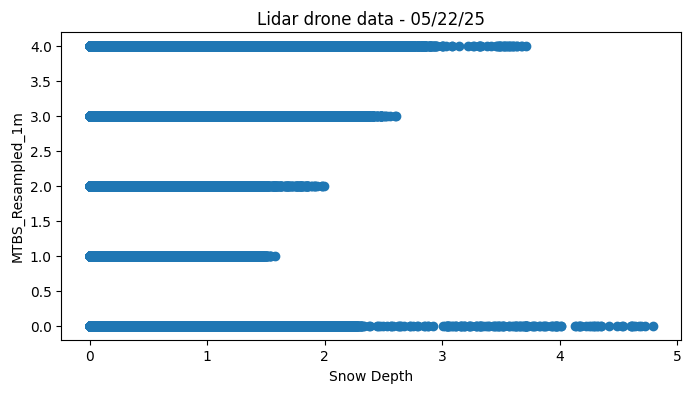

RESOLUTIONS DID NOT MATCH: SD_121225_1m
RESOLUTIONS DID NOT MATCH: SD_121225_1m


In [17]:
for dem in dems:
    #store all depths in array
    depths = dem.z.ravel()

    #store all depths in array after clipping to proper size
    #depths = dem[:2016, :2187].ravel()

    #filter out any points less than -0.1 or greater than 5, if a remaining value is less than 0 it will be set to zero
    depths[depths < -0.1] = None 
    depths[depths > 5.0] = None
    depths[depths < 0] = 0 

    # -------------Box plot ---------------
    # #make box plot of depths
    # makeBoxPlot(depths, processDemName(dem.name), "Snow Depth", "All data (Outliers removed)")

    # -------------Scatter plot -----------
    # #make scatter plot of depths against independent variable
    for iVarDem in iVarDems:
        
        iVarData = iVarDem.z.ravel()

        # DOESN'T NOTICE CLIPPING
        # print("depths-size:" + str(dem.shape))
        # print("independent-size: " + str(iVarDem.shape))

        if len(depths) == len(iVarData):
            makeScatterPlot(depths, iVarData, processDemName(dem.name), "Snow Depth", iVarDem.name)
        else:
            print("RESOLUTIONS DID NOT MATCH: " + dem.name)